
# RNN vs LSTM vs GRU

## Instructions

In this lab, you will build **three text classification models** from scratch:
- RNN
- LSTM
- GRU

---

### Objectives
By the end of this lab, you should be able to:

- Preprocess text data
- Build a vocabulary
- Encode and pad sequences
- Implement RNN, LSTM, and GRU in PyTorch
- Train and evaluate models 
- Compare architectures


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from datasets import load_dataset

from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import re
from collections import Counter

import copy



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# data loading

dataset = load_dataset("ag_news")

# Reduce dataset size for faster training during class
train_data = list(dataset["train"])[:5000]
test_data = list(dataset["test"])[:1000]

print(train_data)
print("Train size:", len(train_data))
print("Test size:", len(test_data))


[{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}, {'text': 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.', 'label': 2}, {'text': "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums.", 'label': 2}, {'text': 'Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\\flows from the main pipeline in southern Iraq after\\intelligence showed a rebel militia could strike\\infrastructure, an oil official said on Saturday.', 


# Part 1 – Text Preprocessing

You must:

1. Write a `tokenize(text)` function.
2. Build a vocabulary using the training set only.
3. Keep only the top 10,000 most frequent words.
4. Add special tokens:
   - `<pad>`
   - `<unk>`
5. Explain in a markdown cell:
   - Why do we not build the vocabulary using the test set?


In [3]:

def tokenize(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    return text.split()

def build_vocab(train_data, max_words=10000):
    counter = Counter()
    for item in train_data:
        counter.update(tokenize(item["text"]))

    vocab = {"<pad>": 0, "<unk>": 1}
    for word, _ in counter.most_common(max_words):
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab, counter


vocab, word_counter = build_vocab(train_data, max_words=10000)
print("Vocab size:", len(vocab))  # deve dar 10002 (10k + 2 especiais, pad e unk)

Vocab size: 10002



# Part 2 – Encoding and Padding

You must:

1. Create an `encode(text)` function.
2. Convert tokens into vocabulary indices.
3. Pad or truncate sequences to a fixed length (e.g., 25).
4. Create a custom `collate()` function.
5. Create train, validation, and test DataLoaders.

Explain:
- Why is padding necessary?
- Why should validation and test loaders not shuffle?


In [4]:
MAX_LEN = 25
PAD_IDX = vocab["<pad>"]
UNK_IDX = vocab["<unk>"]

def encode(text, vocab):
    tokens = tokenize(text)
    return [vocab.get(tok, UNK_IDX) for tok in tokens]

def pad_or_truncate(seq, max_len=MAX_LEN, pad_idx=PAD_IDX):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    return seq[:max_len]

def collate(batch):
    texts = [item["text"] for item in batch]
    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)

    encoded = [encode(t, vocab) for t in texts]
    padded = [pad_or_truncate(seq) for seq in encoded]
    x = torch.tensor(padded, dtype=torch.long)   # [B, MAX_LEN]

    return x, labels


In [5]:
# split treino/val
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(
    train_data,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# loaders
BATCH_SIZE = 64

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(test_data,    batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

# teste rápido
xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)  # esperado: [batch, 25], [batch]


torch.Size([64, 25]) torch.Size([64])



# Part 3 – Model Implementation

Create a class called `Model` that:

- Uses an Embedding layer
- Supports:
  - RNN
  - LSTM
  - GRU
- Uses multiple layers
- Applies dropout
- Outputs class logits

Your model must accept:
- model_type
- vocab_size
- embed_dim
- hidden_dim
- num_layers

Explain:
- The internal difference between RNN, LSTM, and GRU.


In [6]:

class Model(nn.Module):
    def __init__(
        self,
        model_type,      # "rnn" | "lstm" | "gru"
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        num_classes=4,   # AG News
        dropout=0.3,
        pad_idx=0
    ):
        super().__init__()
        self.model_type = model_type.lower()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )

        rnn_dropout = dropout if num_layers > 1 else 0.0

        if self.model_type == "rnn":
            self.rnn = nn.RNN(
                embed_dim, hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout
            )
        elif self.model_type == "lstm":
            self.rnn = nn.LSTM(
                embed_dim, hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout
            )
        elif self.model_type == "gru":
            self.rnn = nn.GRU(
                embed_dim, hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout
            )
        else:
            raise ValueError("model_type must be 'rnn', 'lstm' or 'gru'")

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: [batch, seq_len]
        emb = self.embedding(x)              # [batch, seq_len, embed_dim]
        output, hidden = self.rnn(emb)

        if self.model_type == "lstm":
            h_n, c_n = hidden                # h_n: [num_layers, batch, hidden_dim]
            last_hidden = h_n[-1]            # [batch, hidden_dim]
        else:
            last_hidden = hidden[-1]         # [batch, hidden_dim]

        logits = self.fc(self.dropout(last_hidden))  # [batch, num_classes]
        return logits


In [7]:
model = Model(
    model_type="lstm",
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=4,
    dropout=0.3,
    pad_idx=vocab["<pad>"]
)


In [8]:
xb, yb = next(iter(train_loader))
logits = model(xb)
print(logits.shape)  # [batch_size, 4]


torch.Size([64, 4])



# Part 4 – Training Loop

Implement:

- A full training loop
- Validation loop
- Accuracy computation
- Loss tracking per epoch

Train for 10-50 epochs.

Store:
- train_loss
- val_loss
- train_accuracy
- val_accuracy

Explain:
- Why do we use `model.train()` and `model.eval()`?


In [9]:
model = Model(
    model_type="lstm",          # "rnn", "lstm" ou "gru"
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_layers=2,
    num_classes=4,
    dropout=0.3,
    pad_idx=vocab["<pad>"]
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

num_epochs = 15  # 10-50, como pedido
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_val_acc = -1.0
best_state = copy.deepcopy(model.state_dict())

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

# carregar melhor modelo (pela validação)
model.load_state_dict(best_state)
print(f"Best Val Acc: {best_val_acc:.4f}")


Epoch 01/15 | Train Loss: 1.2886 | Train Acc: 0.3877 | Val Loss: 1.0961 | Val Acc: 0.5640
Epoch 02/15 | Train Loss: 0.8453 | Train Acc: 0.6770 | Val Loss: 0.8033 | Val Acc: 0.7050
Epoch 03/15 | Train Loss: 0.5341 | Train Acc: 0.8205 | Val Loss: 0.7401 | Val Acc: 0.7420
Epoch 04/15 | Train Loss: 0.3779 | Train Acc: 0.8770 | Val Loss: 0.6496 | Val Acc: 0.7790
Epoch 05/15 | Train Loss: 0.2695 | Train Acc: 0.9240 | Val Loss: 0.7214 | Val Acc: 0.7750
Epoch 06/15 | Train Loss: 0.2031 | Train Acc: 0.9417 | Val Loss: 0.7178 | Val Acc: 0.7910
Epoch 07/15 | Train Loss: 0.1634 | Train Acc: 0.9557 | Val Loss: 0.7083 | Val Acc: 0.7750
Epoch 08/15 | Train Loss: 0.1255 | Train Acc: 0.9655 | Val Loss: 0.7795 | Val Acc: 0.7630
Epoch 09/15 | Train Loss: 0.1007 | Train Acc: 0.9725 | Val Loss: 0.8595 | Val Acc: 0.7710
Epoch 10/15 | Train Loss: 0.0920 | Train Acc: 0.9752 | Val Loss: 0.8687 | Val Acc: 0.7620
Epoch 11/15 | Train Loss: 0.0892 | Train Acc: 0.9748 | Val Loss: 0.8370 | Val Acc: 0.7810
Epoch 12/1


# Part 5 – Model Comparison

Train:
- RNN
- LSTM
- GRU

Track validation accuracy and determine:
- Which performs best?
- Why?

Plot:
- Loss curves
- Accuracy curves

Explain signs of overfitting.


In [ ]:
def train_one_model(model_type, epochs=15, lr=1e-3):
    model = Model(
        model_type=model_type,
        vocab_size=len(vocab),
        embed_dim=128,
        hidden_dim=128,
        num_layers=2,
        num_classes=4,
        dropout=0.3,
        pad_idx=vocab["<pad>"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "val_loss": [],
        "train_accuracy": [], "val_accuracy": []
    }

    best_val_acc = -1.0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_acc = run_epoch(val_loader, model, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_type}] Epoch {epoch:02d}/{epochs} | "
              f"Train Acc {train_acc:.4f} | Val Acc {val_acc:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_val_acc


In [11]:
results = {}

for mt in ["rnn", "lstm", "gru"]:
    model, history, best_val = train_one_model(mt, epochs=15, lr=1e-3)
    results[mt] = {"model": model, "history": history, "best_val_acc": best_val}

print("\nBest validation accuracy:")
for mt in results:
    print(f"{mt.upper()}: {results[mt]['best_val_acc']:.4f}")

best_model_type = max(results, key=lambda m: results[m]["best_val_acc"])
best_model = results[best_model_type]["model"]
print(f"\nBest model: {best_model_type.upper()}")


[rnn] Epoch 01/15 | Train Acc 0.3222 | Val Acc 0.3910
[rnn] Epoch 02/15 | Train Acc 0.4990 | Val Acc 0.5120
[rnn] Epoch 03/15 | Train Acc 0.6452 | Val Acc 0.5990
[rnn] Epoch 04/15 | Train Acc 0.7222 | Val Acc 0.6560
[rnn] Epoch 05/15 | Train Acc 0.7800 | Val Acc 0.6880
[rnn] Epoch 06/15 | Train Acc 0.8333 | Val Acc 0.6750
[rnn] Epoch 07/15 | Train Acc 0.8610 | Val Acc 0.7050
[rnn] Epoch 08/15 | Train Acc 0.9058 | Val Acc 0.6840
[rnn] Epoch 09/15 | Train Acc 0.9125 | Val Acc 0.7220
[rnn] Epoch 10/15 | Train Acc 0.9280 | Val Acc 0.6890
[rnn] Epoch 11/15 | Train Acc 0.9490 | Val Acc 0.7240
[rnn] Epoch 12/15 | Train Acc 0.9600 | Val Acc 0.7260
[rnn] Epoch 13/15 | Train Acc 0.9780 | Val Acc 0.7330
[rnn] Epoch 14/15 | Train Acc 0.9822 | Val Acc 0.7220
[rnn] Epoch 15/15 | Train Acc 0.9780 | Val Acc 0.7090
[lstm] Epoch 01/15 | Train Acc 0.3887 | Val Acc 0.5440
[lstm] Epoch 02/15 | Train Acc 0.6663 | Val Acc 0.6820
[lstm] Epoch 03/15 | Train Acc 0.8113 | Val Acc 0.7530
[lstm] Epoch 04/15 | Trai

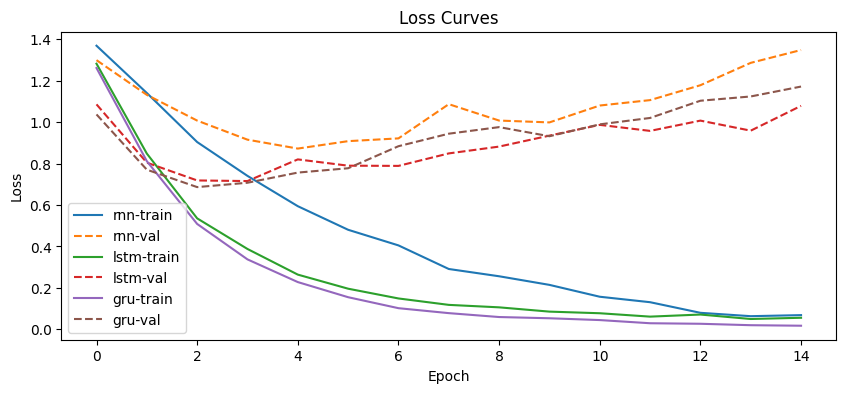

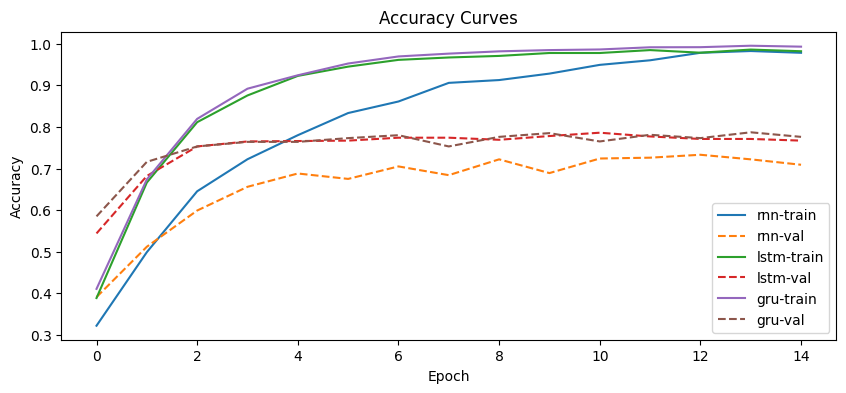

In [12]:
# Plot loss
plt.figure(figsize=(10,4))
for mt in results:
    plt.plot(results[mt]["history"]["train_loss"], label=f"{mt}-train")
    plt.plot(results[mt]["history"]["val_loss"], "--", label=f"{mt}-val")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot accuracy
plt.figure(figsize=(10,4))
for mt in results:
    plt.plot(results[mt]["history"]["train_accuracy"], label=f"{mt}-train")
    plt.plot(results[mt]["history"]["val_accuracy"], "--", label=f"{mt}-val")
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



# Part 6 – Final Evaluation

Using the best model:

1. Evaluate on the test set.
2. Compute test accuracy.
3. Plot a confusion matrix.

Explain:
- Which classes are most confused?
- Why might that happen?


In [13]:
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = best_model(xb)
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(yb.cpu().tolist())

# test accuracy
correct = sum(int(p == y) for p, y in zip(all_preds, all_labels))
test_acc = correct / len(all_labels)
print(f"Test Accuracy ({best_model_type.upper()}): {test_acc:.4f}")


Test Accuracy (GRU): 0.7520


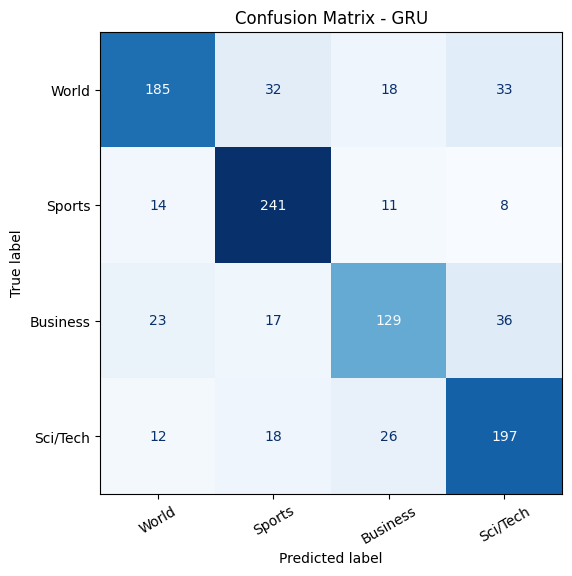

In [14]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

class_names = ["World", "Sports", "Business", "Sci/Tech"]  # AG News labels 0..3
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Confusion Matrix - {best_model_type.upper()}")
plt.xticks(rotation=30)
plt.show()
